# 🚖 Uber Data Analysis Project
### Using Python, NumPy, Pandas & Visualization

## Introduction
This project analyzes Uber ride data to understand demand, cancellations, and cab availability patterns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
# Ride Duration Analysis
ride_durations = np.array([12, 25, 8, 45, 30, 18, 22, 15, 37, 28])

print("Average:", np.mean(ride_durations))
print("Max:", np.max(ride_durations))
print("Min:", np.min(ride_durations))
print("Median:", np.median(ride_durations))
print("Std Dev:", np.std(ride_durations))

Average: 24.0
Max: 45
Min: 8
Median: 23.5
Std Dev: 10.881176406988354


 Load Dataset

In [6]:
df = pd.read_csv('uber_data.csv')
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47


 Data Cleaning

In [7]:
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'])
df['Drop timestamp'] = pd.to_datetime(df['Drop timestamp'])

 Feature Engineering

In [9]:
df['hour'] = df['Request timestamp'].dt.hour

def assign_timeslot(hour):
    if hour <= 4:
        return 'Dawn'
    elif hour <= 9:
        return 'Early Morning'
    elif hour <= 16:
        return 'Noon'
    elif hour <= 21:
        return 'Evening'
    else:
        return 'Night'

df['TimeSlot'] = df['hour'].apply(assign_timeslot)

Data Analysis

In [10]:
df['Status'].value_counts()

,count
Status,
Trip Completed,2831
No Cars Available,2650
Cancelled,1264


In [11]:
df.groupby('hour').size()

,0
hour,
0,99
1,85
2,99
3,92
4,203
5,445
6,398
7,406
8,423


Visualizations:
 1. Ride Status Distribution

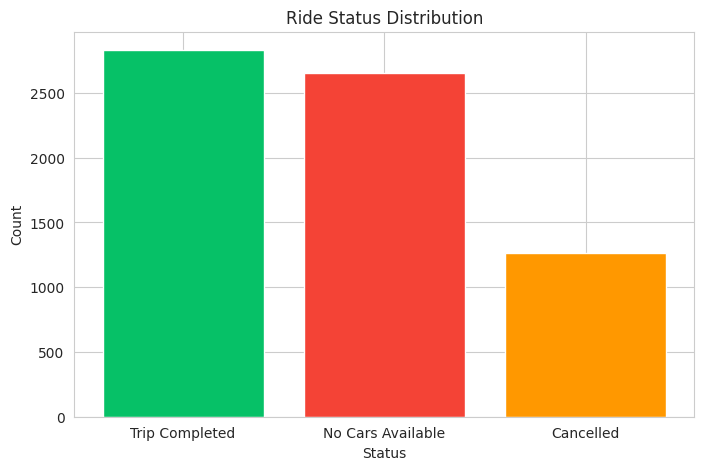

In [13]:
status_counts = df['Status'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(status_counts.index, status_counts.values,
        color=['#06C167', '#F44336', '#FF9800'])
plt.title('Ride Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

2. Hourly Demand

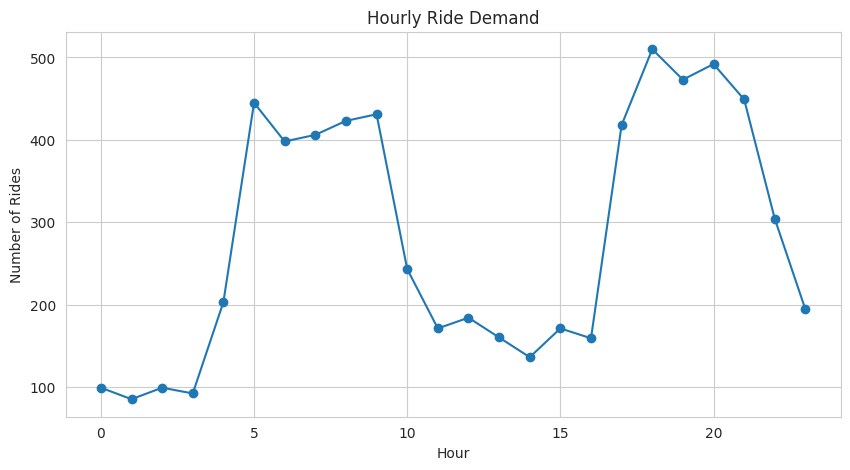

In [14]:
hourly_demand = df.groupby('hour').size()

plt.figure(figsize=(10,5))
plt.plot(hourly_demand.index, hourly_demand.values, marker='o')
plt.title('Hourly Ride Demand')
plt.xlabel('Hour')
plt.ylabel('Number of Rides')
plt.show()

3. Pickup vs Status

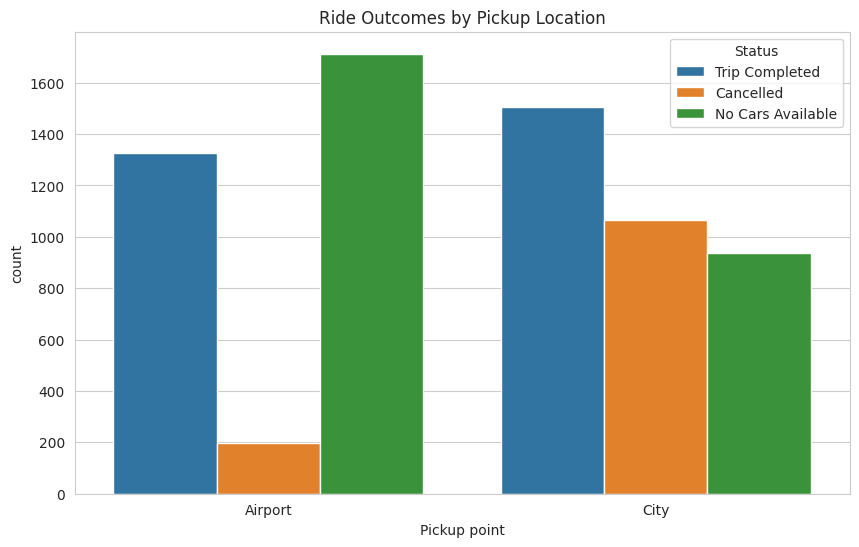

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Pickup point', hue='Status')
plt.title('Ride Outcomes by Pickup Location')
plt.show()

4. City vs Airport

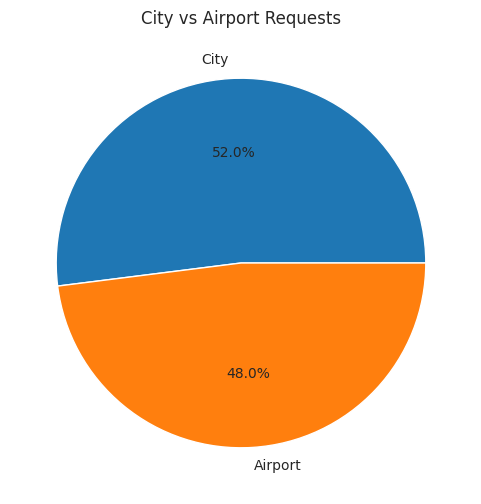

In [16]:
pickup_counts = df['Pickup point'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(pickup_counts.values, labels=pickup_counts.index, autopct='%1.1f%%')
plt.title('City vs Airport Requests')
plt.show()

## Key Insights

- High cancellations are observed in City rides
- Airport shows high "No Cars Available" issues
- Peak demand occurs at specific hours of the day